#### Set-up

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE_DIR=Path("..")/'data'

train_transaction = pd.read_csv(BASE_DIR/'train_transaction.csv')
test_transaction = pd.read_csv(BASE_DIR/'test_transaction.csv')
train_identity = pd.read_csv(BASE_DIR/'train_identity.csv')
test_identity = pd.read_csv(BASE_DIR/'test_identity.csv')

#### Data Overview

In [3]:
# Sanity check before joining
# This shows the percentage of transactions that have identity data.
overlap = train_transaction['TransactionID'].isin(train_identity['TransactionID']).mean()
print(f"Transactions that have identity data: {overlap:.2%}")

# If this returns 0, every transaction has ONE identity row at most
duplicates = train_identity['TransactionID'].duplicated().sum()
print(f"Number of duplicate IDs: {duplicates}")

Transactions that have identity data: 24.42%
Number of duplicate IDs: 0


In [4]:
# Combine train and test
# All identity columns are NaN after joining (Only 24.42% are present in Transaction)
df_train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
df_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

In [5]:
# Clear memory (more memory is always better)
del train_transaction, test_transaction, train_identity, test_identity

In [6]:
print(f'Train: {df_train.shape[0]} rows and {df_train.shape[1]} columns')
print(f'Test: {df_test.shape[0]} rows and {df_test.shape[1]} columns')

Train: 590540 rows and 434 columns
Test: 506691 rows and 433 columns


In [7]:
df_train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [8]:
df_test.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Create a dummy column: 1 if we have identity data, 0 if we don't
df_train['has_identity'] = df_train['id_01'].notnull().astype(int)

fraud_with_id = df_train.groupby('has_identity')['isFraud'].mean()
print(f"Fraud rate with identity info: {fraud_with_id[1]:.2%}")
print(f"Fraud rate without identity info: {fraud_with_id[0]:.2%}")

del df_train['has_identity']

Fraud rate with identity info: 7.85%
Fraud rate without identity info: 2.09%


In [10]:
print(df_train.isnull().any().sum())

414


In [11]:
print(df_train['TransactionAmt'].skew().round(2))

14.37


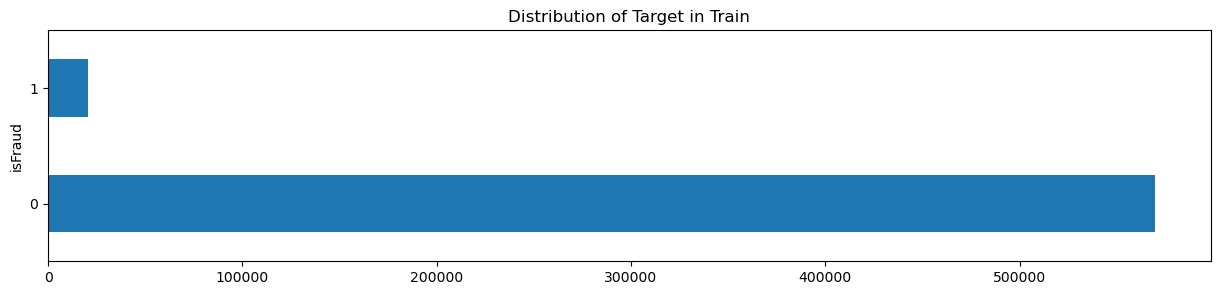

In [12]:
df_train.groupby('isFraud').count()['TransactionID'].plot(kind='barh', title='Distribution of Target in Train', figsize=(15, 3))
plt.show()

#### TransactionAmt

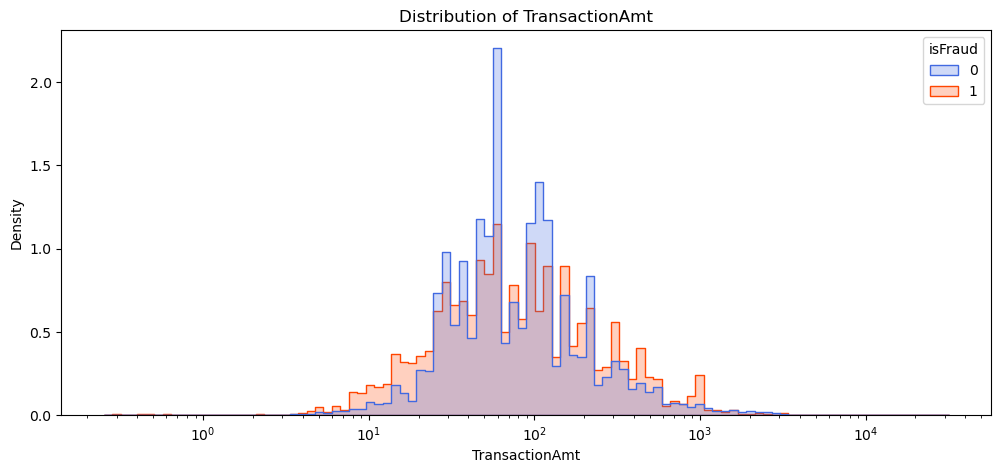

In [13]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df_train,
    x='TransactionAmt',
    hue='isFraud',
    bins=100,
    element='step',
    stat='density', #Normalize the counts (class imbalance)
    common_norm=False,
    log_scale=True, # Check distribution
    palette={0: 'royalblue', 1: 'orangered'}
)

plt.title("Distribution of TransactionAmt")
plt.show()

The log-transformed transaction amounts show that fraudulent transactions are more concentrated in very low and unusual high ranges, whereas most legitimate transactions cluster in mid-range amounts. While the log transformation reduces skewness and allows better visualization, there is still considerable overlap between fraud and non-fraud transactions. This suggests that TransactionAmt is moderately predictive but not sufficient for reliable fraud detection on its own.

In [14]:
#plt.figure(figsize=(12, 5))
#
#sns.histplot(
#    data=df_train[df_train['isFraud'] == 1],  # Filter for positive class
#    x='TransactionAmt',
#    bins=100,
#    element='step',
#    #stat='density', #Normalize the counts (class imbalance)
#    common_norm=False
#)
#
#plt.title("Distribution of isFraud")
#plt.show()

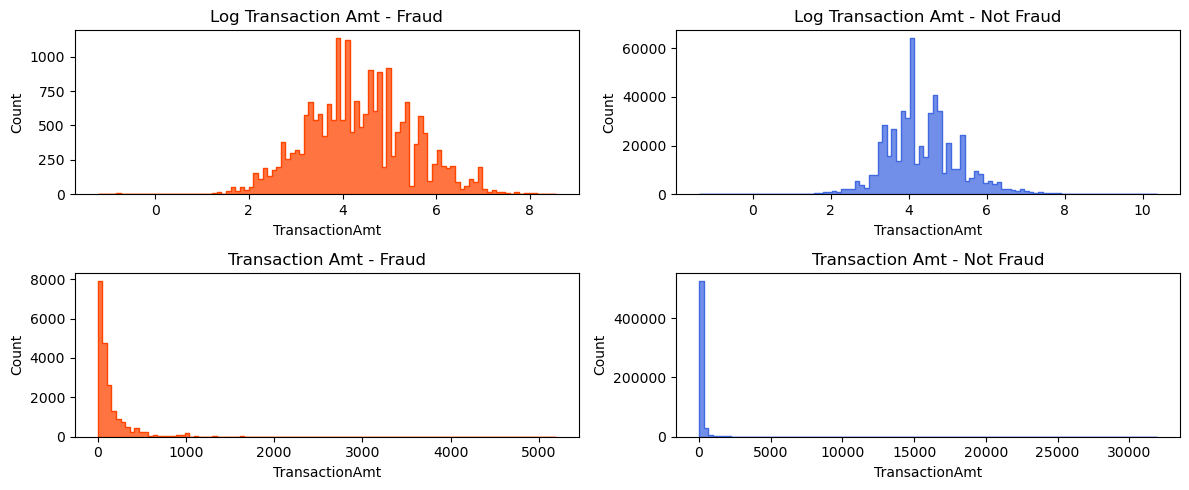

In [15]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 5))

# Fraud - Log
sns.histplot(
    data=df_train[df_train['isFraud'] == 1],
    x=df_train.loc[df_train['isFraud'] == 1, 'TransactionAmt'].apply(np.log),
    bins=100,
    ax=ax1,
    color='orangered',
    element='step'
)
ax1.set_title('Log Transaction Amt - Fraud')

# Not Fraud - Log
sns.histplot(
    data=df_train[df_train['isFraud'] == 0],
    x=df_train.loc[df_train['isFraud'] == 0, 'TransactionAmt'].apply(np.log),
    bins=100,
    ax=ax2,
    color='royalblue',
    element='step'
)
ax2.set_title('Log Transaction Amt - Not Fraud')

# Fraud - Raw
sns.histplot(
    data=df_train[df_train['isFraud'] == 1],
    x='TransactionAmt',
    bins=100,
    ax=ax3,
    color='orangered',
    element='step'
)
ax3.set_title('Transaction Amt - Fraud')

# Not Fraud - Raw
sns.histplot(
    data=df_train[df_train['isFraud'] == 0],
    x='TransactionAmt',
    bins=100,
    ax=ax4,
    color='royalblue',
    element='step'
)
ax4.set_title('Transaction Amt - Not Fraud')

plt.tight_layout()
plt.show()

Fraudulent transactions overlap with non-Fraudulent ones, especially at low transaction amounts, which makes it hard to distinguish them from one another. They also both follow a similar distribution, but the fraudulent ones have. a larger spread.

#### TransactionDT

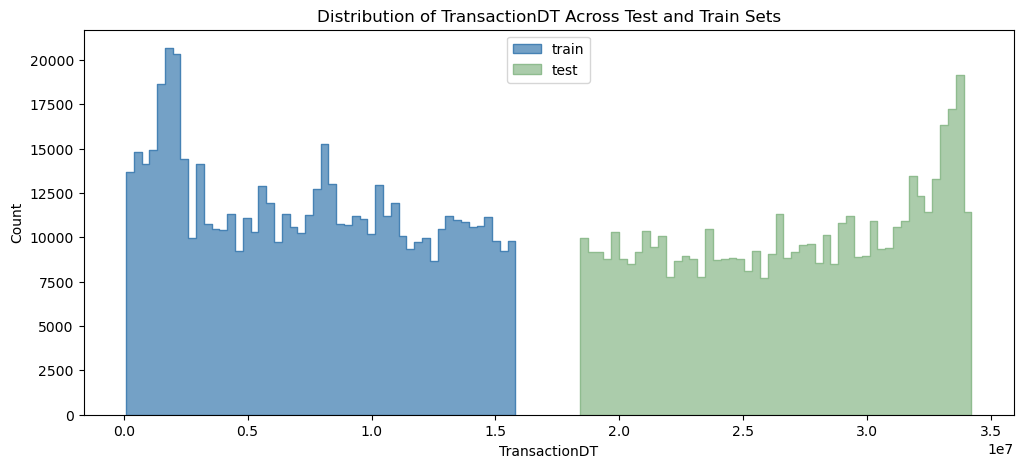

In [16]:
plt.figure(figsize=(12, 5))

sns.histplot(df_train['TransactionDT'],
             label='train', 
             element='step',
             bins=50,
             color='steelblue'
             )

sns.histplot(df_test['TransactionDT'], 
             label='test', 
             element='step',
             bins=50,
             color='darkseagreen'
             )

plt.title('Distribution of TransactionDT Across Test and Train Sets')
plt.legend()
plt.show()

There is a mismatch in the way TransactionDT is distributed across the train and test dataset. In the test set, the timestamp is to the left, while in the train set, it is towards the right. While I am unsure what it might mean, we might have to process it for modeling.

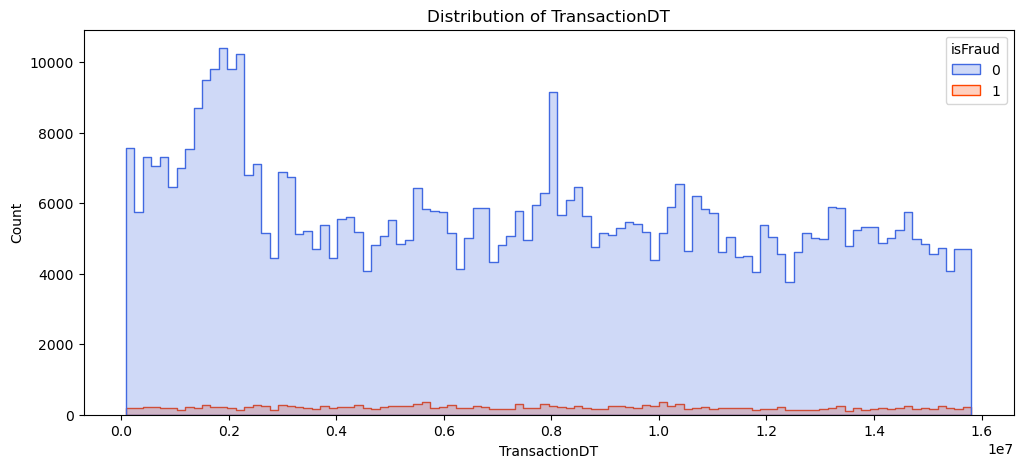

In [17]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df_train,
    x='TransactionDT',
    hue='isFraud',
    bins=100,
    element='step',
    common_norm=False,
    palette={0: 'royalblue', 1: 'orangered'}
)

plt.title("Distribution of TransactionDT")
plt.show()

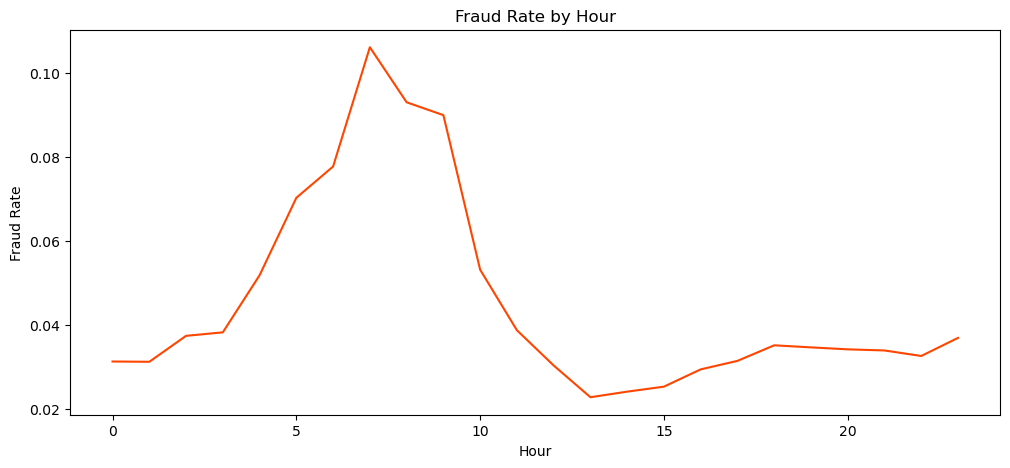

In [18]:
# Engineer timeline from transaction dates ('TransactionDT')
# Assuming TransactionDT starts at 0 (Midnight)
df_train['hours'] = (df_train['TransactionDT'] // 3600) % 24

plt.figure(figsize=(12, 5))

sns.lineplot(data=df_train.groupby('hours')['isFraud'].mean(),
             color='orangered'
             )

plt.title('Fraud Rate by Hour')
plt.ylabel('Fraud Rate')
plt.xlabel('Hour')
plt.show()

df_train.drop(columns=['hours'], inplace=True)

#### Missing Values

In [19]:
# Calculate the proportion of NAs for every column
na_count = df_train.isna().mean()

# Filter only the columns that are missing 50% or more of the data
missing_50_plus = na_count[na_count >= 0.50]

# Sort them in descending order so the emptiest columns are at the top
missing_50_labels = missing_50_plus.sort_values(ascending=False)

print(f'Total missing values above 50%: {len(missing_50_plus)} out of {len(df_train.columns)}')
print(missing_50_labels.head(5)*100)

Total missing values above 50%: 214 out of 434
id_24    99.196159
id_25    99.130965
id_08    99.127070
id_07    99.127070
id_21    99.126393
dtype: float64


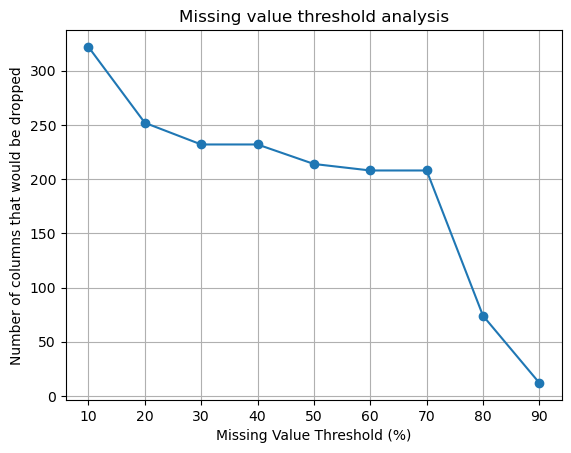

In [20]:

na_proportions = df_train.isna().mean()

missing_10_plus = na_proportions[na_proportions >= 0.10]
missing_20_plus = na_proportions[na_proportions >= 0.20]
missing_30_plus = na_proportions[na_proportions >= 0.30]
missing_40_plus = na_proportions[na_proportions >= 0.40]
missing_50_plus = na_proportions[na_proportions >= 0.50]
missing_60_plus = na_proportions[na_proportions >= 0.60]
missing_70_plus = na_proportions[na_proportions >= 0.70]
missing_80_plus = na_proportions[na_proportions >= 0.80]
missing_90_plus = na_proportions[na_proportions >= 0.90]

thresholds = range(10, 100, 10)
counts = [len(na_proportions[na_proportions >= t/100]) for t in thresholds]

plt.plot(thresholds, counts, marker='o')
plt.xlabel('Missing Value Threshold (%)')
plt.ylabel('Number of columns that would be dropped')
plt.title('Missing value threshold analysis')
plt.grid(True)
plt.show()

#### IDs

The ID columns have a mixture of numerical and categorical variables.

In [21]:
# List of all ID columns
id_cols = [f'id_{i:02d}' for i in range(1, 39)]

summary = []

for col in id_cols:
    if col in df_train.columns:
        summary.append({
            'id': col,
            'unique_values': df_train[col].nunique(),
            'missing_values': (df_train[col].isnull().mean() * 100).round(2),
            'dtype': df_train[col].dtype
        })

id_summary_df = pd.DataFrame(summary) # Convert to DataFrame
id_summary_df.sort_values(by='missing_values', ascending=False) # Sort by missing percentage

,id,unique_values,missing_values,dtype
23,id_24,12,99.20,float64
20,id_21,490,99.13,float64
6,id_07,84,99.13,float64
7,id_08,94,99.13,float64
24,id_25,341,99.13,float64
25,id_26,95,99.13,float64
22,id_23,3,99.12,object
26,id_27,2,99.12,object
21,id_22,25,99.12,float64
17,id_18,18,92.36,float64


- id_02 is particularly interesting because of the 115655 unique values it has.
- id_07, id_08, and id_21 through id_27 have over 99% missing data.
- id_02 has 115655 unique values, an outlier compared to the other ids.
- id_32 has 4 unique values and is listed as a float, meaning it could be a categorical feature that is using numbers as bins.

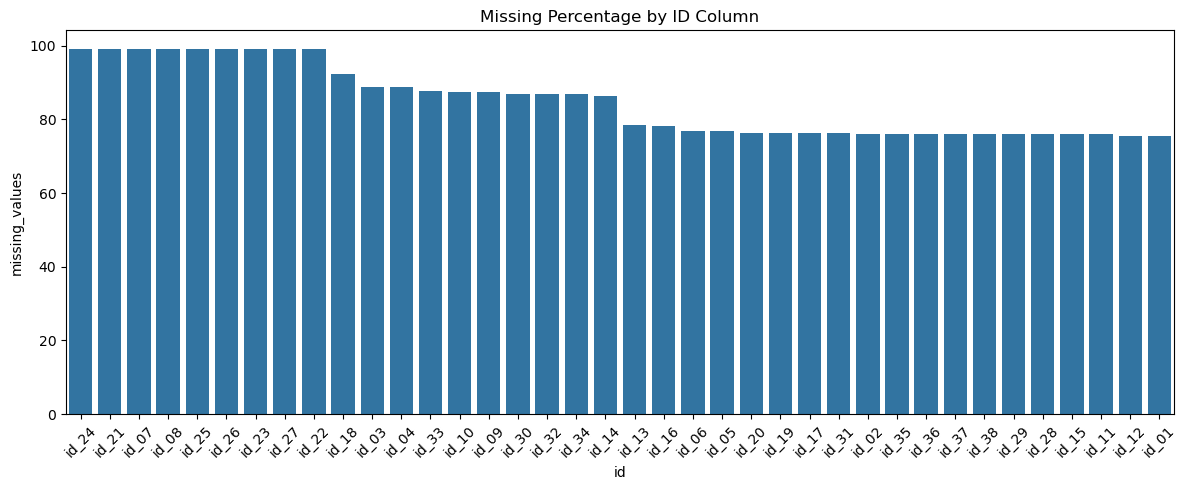

In [22]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=id_summary_df.sort_values('missing_values', ascending=False).reset_index(),
    x='id',
    y='missing_values'
)

plt.title("Missing Percentage by ID Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# Is dropping the columns with a high number of missing values the right move?
#drop_cols = id_summary_df[id_summary_df['missing_%'] > 90].index
#df_train = df_train.drop(columns=drop_cols)

#### DeviceInfo and DeviceType

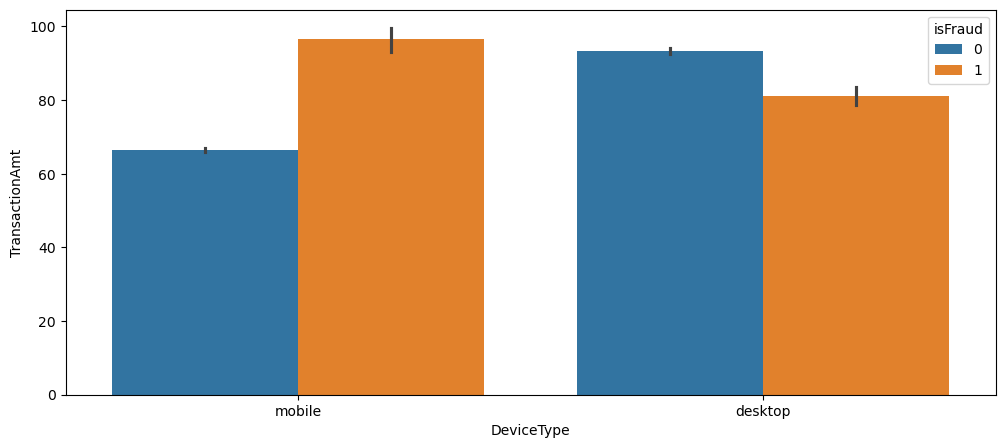

In [24]:
# TransactionDT
plt.figure(figsize=(12, 5))

sns.barplot(
    data=df_train,
    x='DeviceType',
    y='TransactionAmt',
    hue='isFraud'
    #bins=100,
    #element='step',
    #common_norm=False,
    #palette={0: 'royalblue', 1: 'orangered'}
)

plt.show()

#### ProductCD

In [25]:
df_train['ProductCD'].value_counts(normalize=True)

ProductCD
W    0.744522
C    0.116028
R    0.063838
H    0.055922
S    0.019690
Name: proportion, dtype: float64

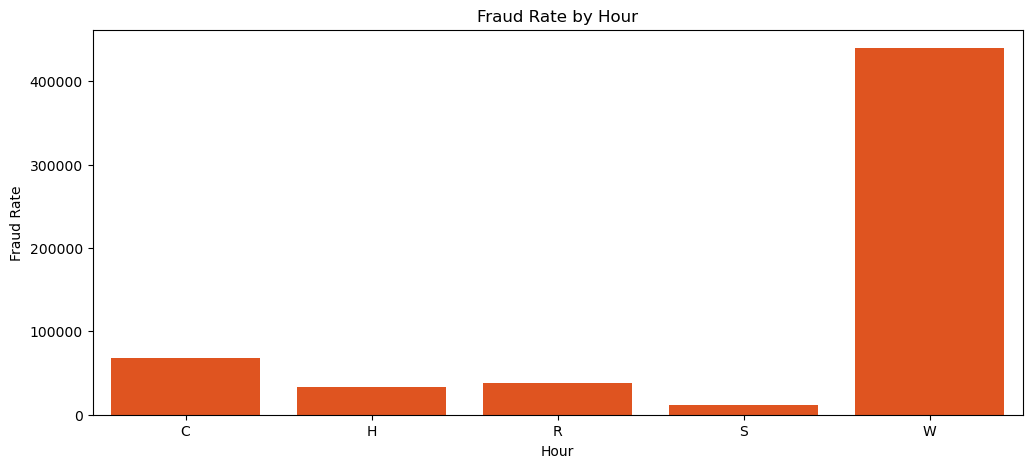

In [26]:
plt.figure(figsize=(12, 5))

sns.barplot(data=df_train.groupby('ProductCD')['TransactionID'].count(),
            color='orangered'
            )

plt.title('Fraud Rate by Hour')
plt.ylabel('Fraud Rate')
plt.xlabel('Hour')
plt.show()

#### card1 to card6

In [27]:
card_cols = []

for col in df_train.columns:
    if 'card' in col:
        card_cols.append(col)
df_train[card_cols].head(5)

#df_train.filter(like='card').head()

,card1,card2,card3,card4,card5,card6
0,13926,NaN,150.0,discover,142.0,credit
1,2755,404.0,150.0,mastercard,102.0,credit
2,4663,490.0,150.0,visa,166.0,debit
3,18132,567.0,150.0,mastercard,117.0,debit
4,4497,514.0,150.0,mastercard,102.0,credit


In [28]:
# Check how many missing values we are dealing with
missing_counts = df_train[card_cols].isna().sum()
print(f"Features with 0 missing values: {(missing_counts == 0).sum()}")
print(f"Features with missing values: {(missing_counts > 0).sum()}")
print(f"Maximum missing values in a single column: {missing_counts.max():,}")

del missing_counts

Features with 0 missing values: 1
Features with missing values: 5
Maximum missing values in a single column: 8,933


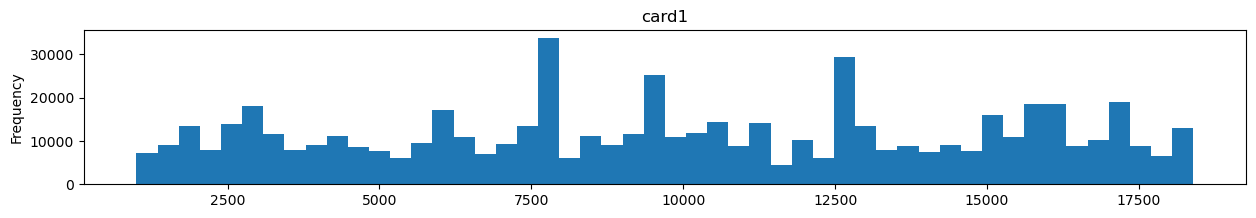

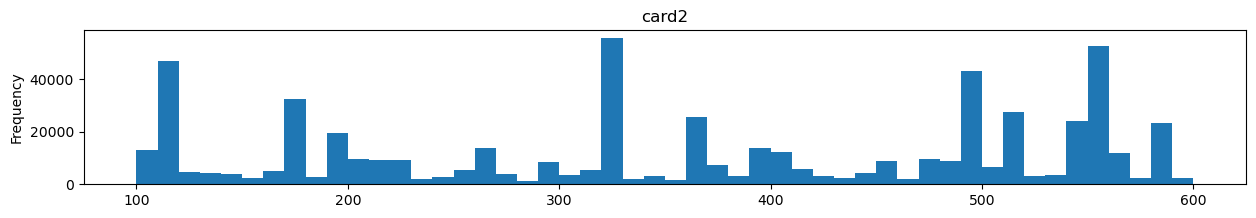

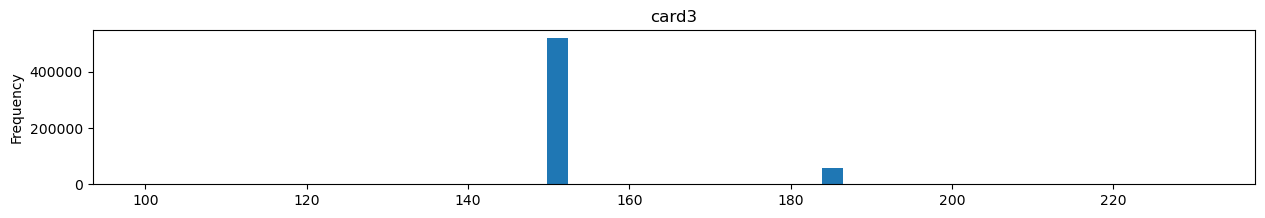

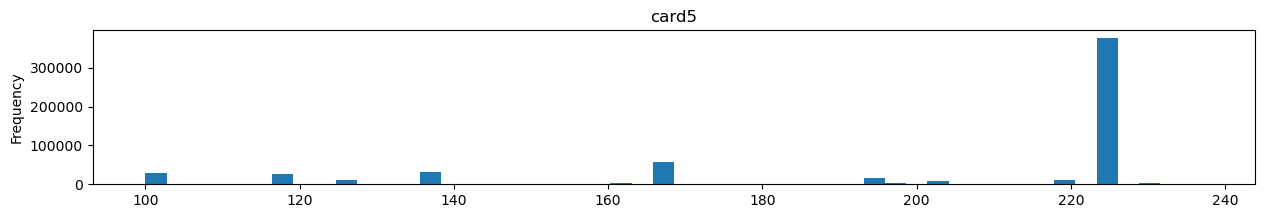

In [29]:
for c in card_cols:
    if df_train[c].dtype in ['float64','int64']:
        df_train[c].plot(
            kind='hist',
            title=c,
            bins=50,
            figsize=(15, 2)
            )
    plt.show()

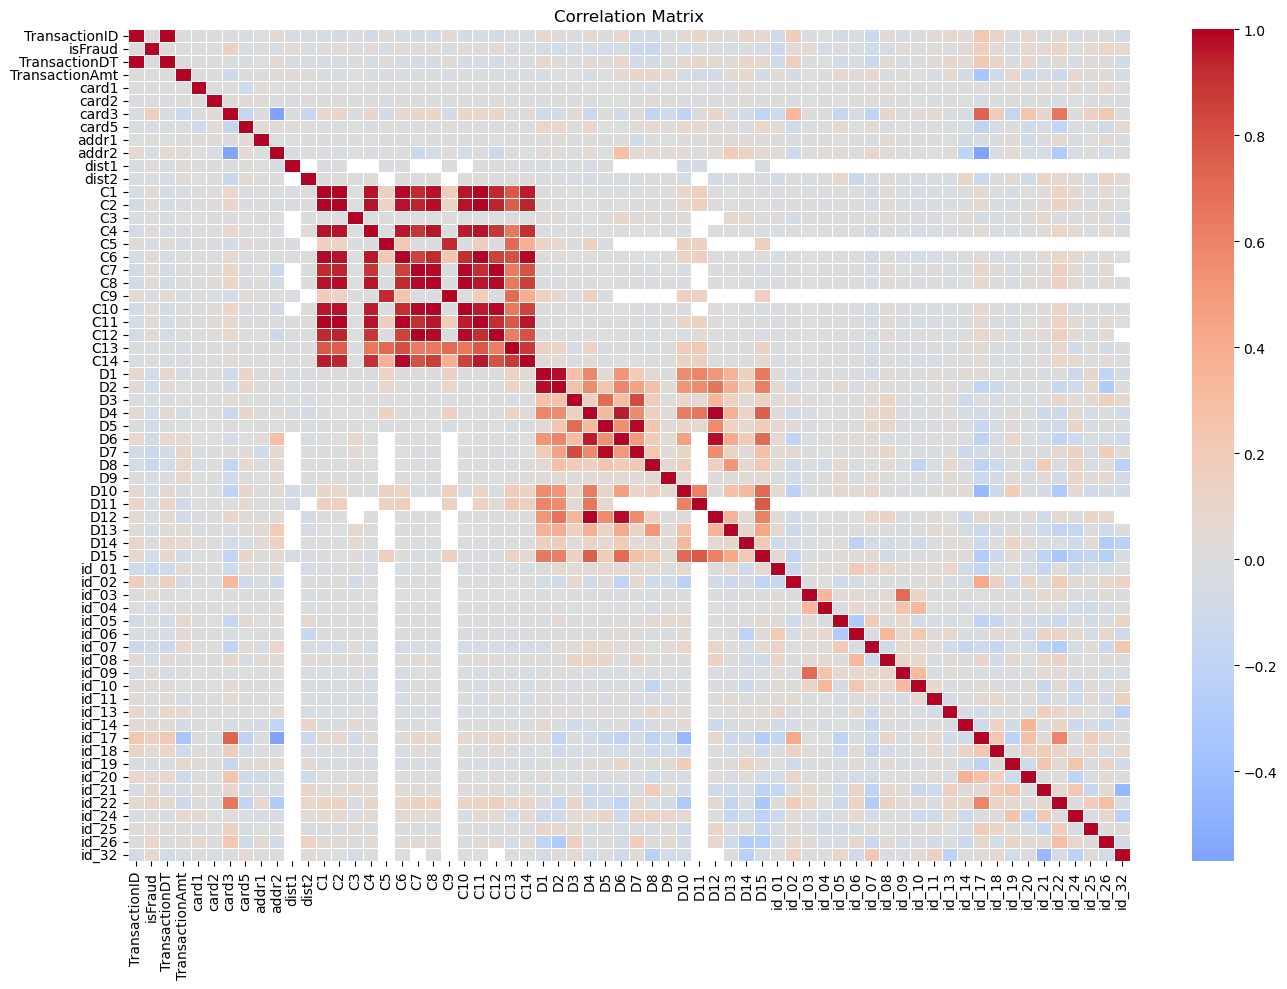

In [71]:
# Correlation matrix
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if not c.startswith('V') and c != 'v_mean']

corr = df_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

#### V1 to V339

In [30]:
v_cols = []

for col in df_train.columns:
    if 'V' == col[0]:
        v_cols.append(col)

df_train[v_cols].head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
df_train[v_cols].describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,0.999945,1.045204,1.078075,0.846456,0.876991,1.045686,1.072870,1.027704,1.041529,0.463915,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,0.007390,0.240133,0.320890,0.440053,0.475902,0.239385,0.304779,0.186069,0.226339,0.521522,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,1.000000,8.000000,9.000000,6.000000,6.000000,9.000000,9.000000,8.000000,8.000000,4.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


In [32]:
# Check how many missing values we are dealing with
missing_counts = df_train[v_cols].isna().sum()
print(f"Features with 0 missing values: {(missing_counts == 0).sum()}")
print(f"Features with missing values: {(missing_counts > 0).sum()}")
print(f"Maximum missing values in a single column: {missing_counts.max():,}")

del missing_counts

Features with 0 missing values: 0
Features with missing values: 339
Maximum missing values in a single column: 508,595


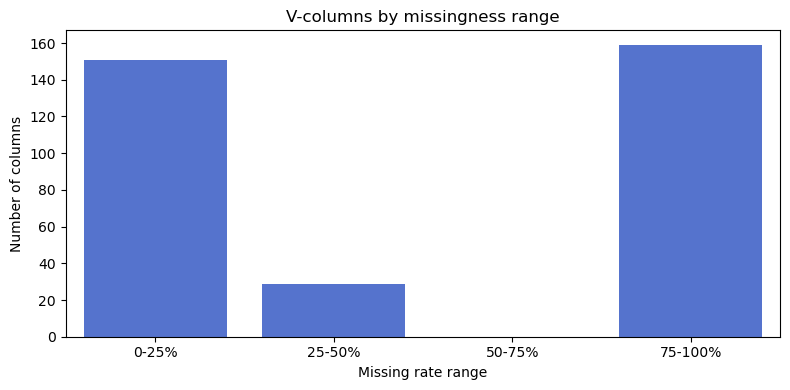

In [65]:
na_proportions = df_train[v_cols].isna().mean()

missing_values = pd.cut(
    na_proportions,
    bins=[0, 0.25, 0.50, 0.75, 1],
    labels=['0-25%', '25-50%', '50-75%', '75-100%']
).value_counts().sort_index().reset_index()

missing_values.columns = ['missing_range', 'count']

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=missing_values,
    x='missing_range',
    y='count',
    color='royalblue',
    ax=ax
    )

ax.set_title('V-columns by missingness range')
ax.set_xlabel('Missing rate range')
ax.set_ylabel('Number of columns')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'log transformed mean of V-columns (Not Fraud)')

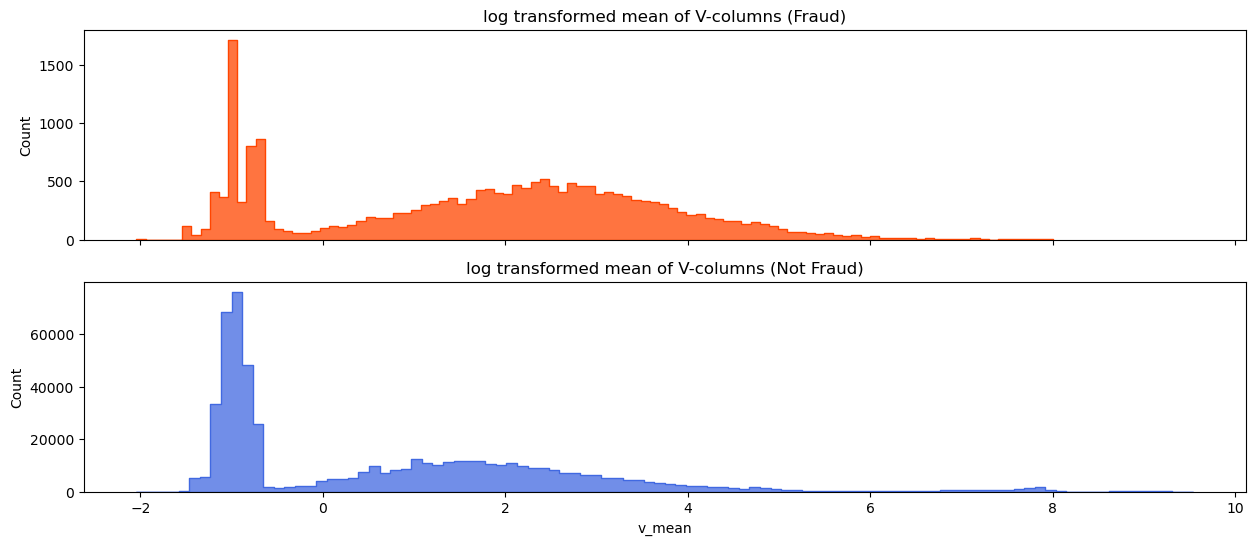

In [34]:
df_train['v_mean'] = df_train[v_cols].mean(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(15, 6))

sns.histplot(
    data=df_train.loc[df_train['isFraud'] == 1]['v_mean'].apply(np.log),
    bins=100,
    ax=ax1,
    color='orangered',
    element='step'
)

sns.histplot(
    data=df_train.loc[df_train['isFraud'] == 0]['v_mean'].apply(np.log),
    bins=100,
    ax=ax2,
    color='royalblue',
    element='step'
)

ax1.set_title('log transformed mean of V-columns (Fraud)')
ax2.set_title('log transformed mean of V-columns (Not Fraud)')